In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Train shape:", train_images.shape)
print("Test shape:", test_images.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [4]:
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

print("After reshape:", train_images.shape)

After reshape: (60000, 28, 28, 1)


In [5]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.1, random_state=42
)

print("Final Train:", train_images.shape)
print("Validation:", val_images.shape)
print("Test:", test_images.shape)

Final Train: (54000, 28, 28, 1)
Validation: (6000, 28, 28, 1)
Test: (10000, 28, 28, 1)


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training start
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=15,
    batch_size=64
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.7922 - loss: 0.5683 - val_accuracy: 0.8587 - val_loss: 0.3858
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.8625 - loss: 0.3762 - val_accuracy: 0.8805 - val_loss: 0.3175
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.8821 - loss: 0.3264 - val_accuracy: 0.8840 - val_loss: 0.3020
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.8943 - loss: 0.2916 - val_accuracy: 0.8933 - val_loss: 0.2835
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9009 - loss: 0.2683 - val_accuracy: 0.9032 - val_loss: 0.2705
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.9098 - loss: 0.2466 - val_accuracy: 0.9082 - val_loss: 0.2548
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9129 - loss: 0.2334 - val_accuracy: 0.9060 - val_loss: 0.2550
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9197 - loss: 0.2157 - 

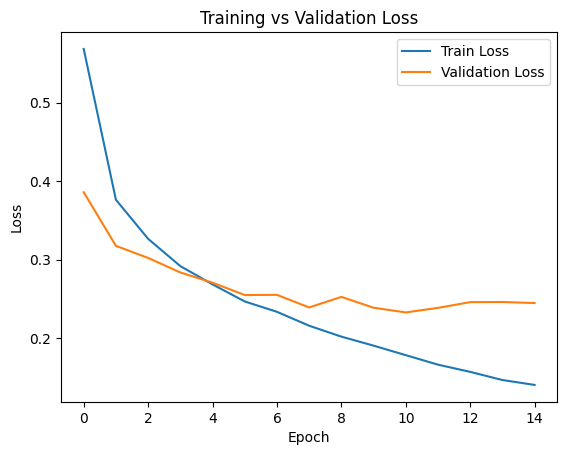

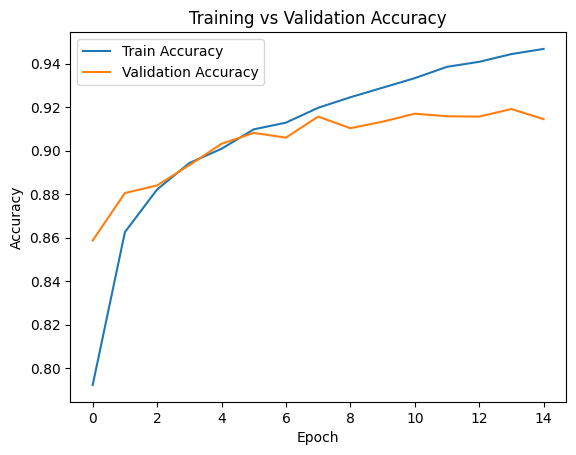

In [8]:
import matplotlib.pyplot as plt

# Loss curve
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

# Accuracy curve
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig('accuracy_curve.png')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


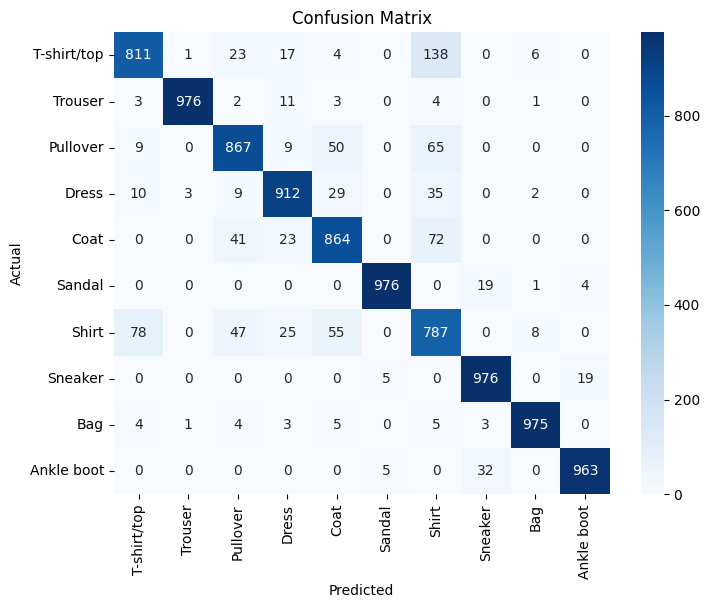

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.81      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.87      0.87      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.86      0.86      0.86      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.71      0.79      0.75      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

# Classification Report
print(classification_report(test_labels, predicted_labels, target_names=class_names))

In [11]:
model.save('fashion_mnist_model.keras')

In [14]:
from PIL import Image
import numpy as np
import os

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

os.makedirs("test_samples", exist_ok=True)

for i in range(6):
    sample = (test_images[i].reshape(28,28) * 255).astype(np.uint8)
    img = Image.fromarray(sample)
    actual_label = class_names[test_labels[i]]

    filename = f"test_samples/{i}_{actual_label.replace('/', '-')}.png"
    img.save(filename)
    print(f"Saved: {filename}")

Saved: test_samples/0_Ankle boot.png
Saved: test_samples/1_Pullover.png
Saved: test_samples/2_Trouser.png
Saved: test_samples/3_Trouser.png
Saved: test_samples/4_Shirt.png
Saved: test_samples/5_Trouser.png
